# Intent–Behavior Deviation in Smart Contracts
## Notebook 4: Combined Results — All Tiers
**Aggregates Tier 1 + Tier 2 + Tier 3 results into paper-ready charts**
> Run AFTER notebooks 1, 2, and 3 have completed and saved their JSON files.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, seaborn as sns, json, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']=130
TIER_COLORS={'Tier 1':'#3498db','Tier 2':'#e67e22','Tier 3':'#8e44ad'}
SEED=42
print('Imports OK')

Imports OK


In [2]:
import glob

def find_file(name):
    matches = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    if not matches:
        raise FileNotFoundError(f" {name} not found in /kaggle/input/")
    print(f" Found {name} at: {matches[0]}")
    return matches[0]

with open(find_file('tier1_raw_results.json')) as f: t1 = json.load(f)
with open(find_file('tier2_raw_results.json')) as f: t2 = json.load(f)
with open(find_file('tier3_raw_results.json')) as f: t3 = json.load(f)

rows=[]
for name in ['Logistic Regression','Random Forest','SVM','XGBoost']:
    if name in t1:
        rows.append({'Model':name,'Tier':'Tier 1',
                     'F1_Full':t1[name]['full_f1_mean'],'F1_Full_std':t1[name]['full_f1_std'],
                     'AUC_Full':t1[name]['full_auc_mean'],
                     'F1_Bal':t1[name]['bal_f1_mean'],'AUC_Bal':t1[name]['bal_auc_mean']})

rows.append({'Model':'MLP (3-Layer)','Tier':'Tier 2',
             'F1_Full':t2['MLP_3Layer']['full_f1_mean'],'F1_Full_std':t2['MLP_3Layer']['full_f1_std'],
             'AUC_Full':t2['MLP_3Layer']['full_auc_mean'],
             'F1_Bal':t2['MLP_3Layer']['bal_f1_mean'],'AUC_Bal':t2['MLP_3Layer']['bal_auc_mean']})

rows.append({'Model':'Deep MLP (5-Layer)','Tier':'Tier 3',
             'F1_Full':t3['DeepMLP']['full_f1_mean'],'F1_Full_std':t3['DeepMLP']['full_f1_std'],
             'AUC_Full':t3['DeepMLP']['full_auc_mean'],
             'F1_Bal':t3['DeepMLP']['bal_f1_mean'],'AUC_Bal':t3['DeepMLP']['bal_auc_mean']})

df_all=pd.DataFrame(rows)
df_all.to_csv('combined_results.csv',index=False)
print('=== MASTER RESULTS ===')
print(df_all[['Model','Tier','F1_Full','AUC_Full','F1_Bal','AUC_Bal']].to_string(index=False))

 Found tier1_raw_results.json at: /kaggle/input/notebooks/mohuamridha/notebook-1-tier1-classical/tier1_raw_results.json
 Found tier2_raw_results.json at: /kaggle/input/notebooks/mohuamridha/notebook-2-tier2-mlp/tier2_raw_results.json
 Found tier3_raw_results.json at: /kaggle/input/notebooks/mohuamridha/notebook-3-tier3-deep/tier3_raw_results.json
=== MASTER RESULTS ===
              Model   Tier  F1_Full  AUC_Full   F1_Bal  AUC_Bal
Logistic Regression Tier 1 0.967597  0.987720 0.966722 0.992791
      Random Forest Tier 1 0.974494  0.996141 0.970122 0.995628
                SVM Tier 1 0.969804  0.995532 0.968180 0.995049
            XGBoost Tier 1 0.974246  0.995961 0.967688 0.995703
      MLP (3-Layer) Tier 2 0.974865  0.991239 0.975526 0.992316
 Deep MLP (5-Layer) Tier 3 0.974809  0.991271 0.976017 0.991937


---
## Visualizations

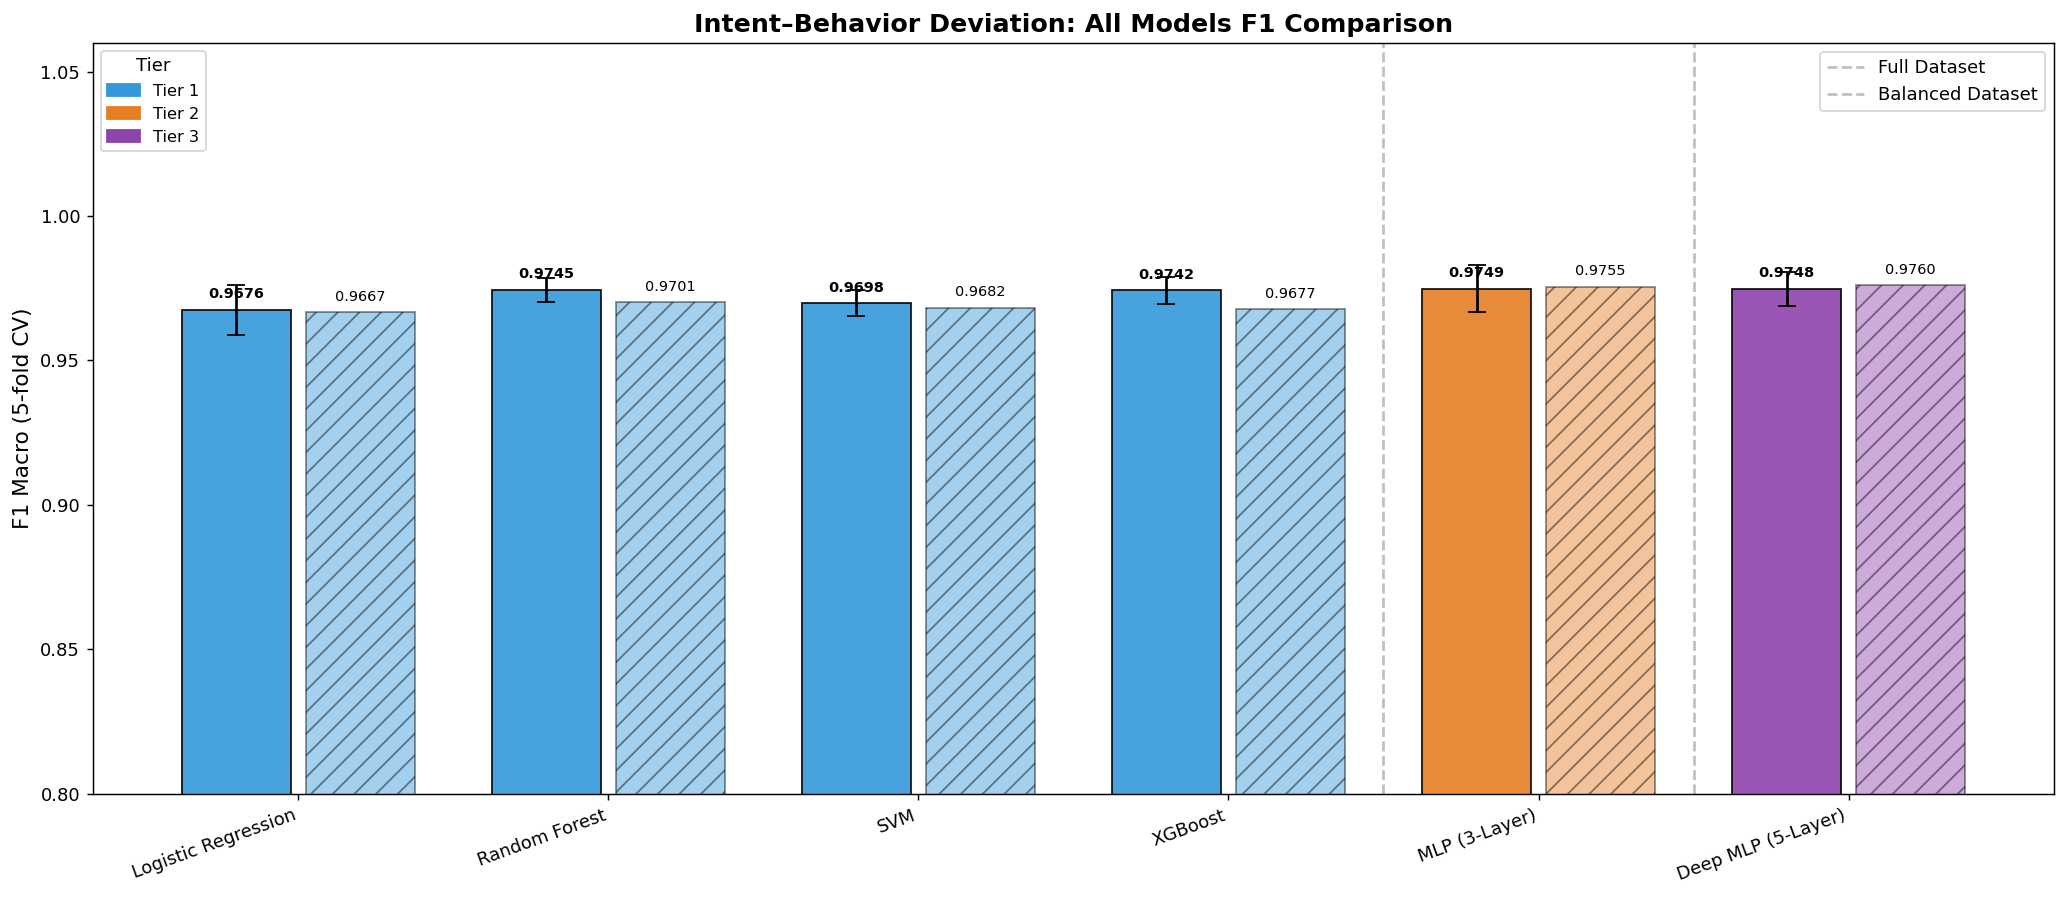

In [3]:
# VIZ 1: Master F1 — all models, Full vs Balanced
models=df_all['Model'].tolist(); tiers=df_all['Tier'].tolist()
f1_f=df_all['F1_Full'].tolist(); f1_b=df_all['F1_Bal'].tolist()
f1_std=df_all['F1_Full_std'].tolist()
x=np.arange(len(models))
bar_c=[TIER_COLORS[t] for t in tiers]
fig,ax=plt.subplots(figsize=(16,7))
b1=ax.bar(x-0.2,f1_f,0.35,label='Full Dataset',   color=bar_c,edgecolor='black',yerr=f1_std,capsize=5,alpha=0.9)
b2=ax.bar(x+0.2,f1_b,0.35,label='Balanced Dataset',color=bar_c,edgecolor='black',alpha=0.45,hatch='//')
for bar,v in zip(b1,f1_f): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.4f}',ha='center',va='bottom',fontsize=8,fontweight='bold')
for bar,v in zip(b2,f1_b): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.4f}',ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models,rotation=20,ha='right',fontsize=10)
ax.set_ylabel('F1 Macro (5-fold CV)',fontsize=12); ax.set_ylim(0.8,1.06)
ax.set_title('Intent–Behavior Deviation: All Models F1 Comparison',fontsize=14,fontweight='bold')
ax.axvline(3.5,color='gray',linestyle='--',alpha=0.5); ax.axvline(4.5,color='gray',linestyle='--',alpha=0.5)
tier_patches=[mpatches.Patch(color=c,label=t) for t,c in TIER_COLORS.items()]
leg1=ax.legend(handles=tier_patches,loc='upper left',title='Tier',fontsize=9)
ax.add_artist(leg1); ax.legend(['Full Dataset','Balanced Dataset'],loc='upper right',fontsize=10)
plt.tight_layout()
plt.savefig('combined_01_all_f1.png',bbox_inches='tight',dpi=150); plt.show()

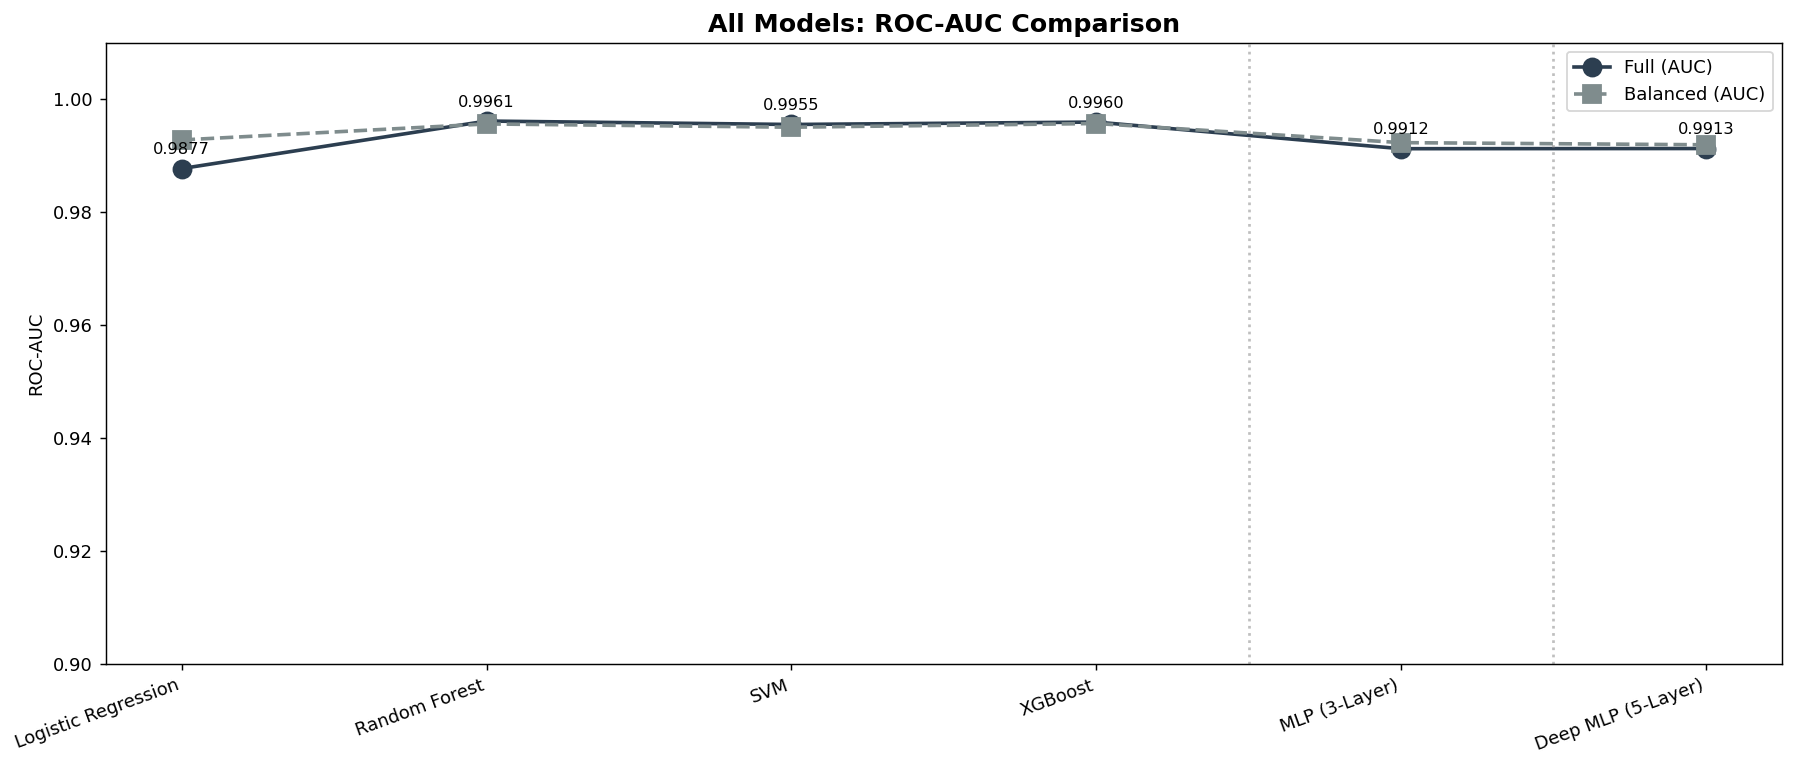

In [4]:
# VIZ 2: ROC-AUC comparison
auc_f=df_all['AUC_Full'].tolist(); auc_b=df_all['AUC_Bal'].tolist()
fig,ax=plt.subplots(figsize=(14,6))
ax.plot(models,auc_f,'o-',lw=2,ms=10,color='#2c3e50',label='Full (AUC)')
ax.plot(models,auc_b,'s--',lw=2,ms=10,color='#7f8c8d',label='Balanced (AUC)')
for i,(f,b) in enumerate(zip(auc_f,auc_b)):
    ax.annotate(f'{f:.4f}',(i,f),xytext=(0,8),textcoords='offset points',ha='center',fontsize=9)
ax.axvline(3.5,color='gray',linestyle=':',alpha=0.5); ax.axvline(4.5,color='gray',linestyle=':',alpha=0.5)
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.9,1.01)
ax.set_title('All Models: ROC-AUC Comparison',fontsize=14,fontweight='bold')
ax.set_xticks(range(len(models))); ax.set_xticklabels(models,rotation=20,ha='right'); ax.legend()
plt.tight_layout()
plt.savefig('combined_02_all_auc.png',bbox_inches='tight',dpi=150); plt.show()

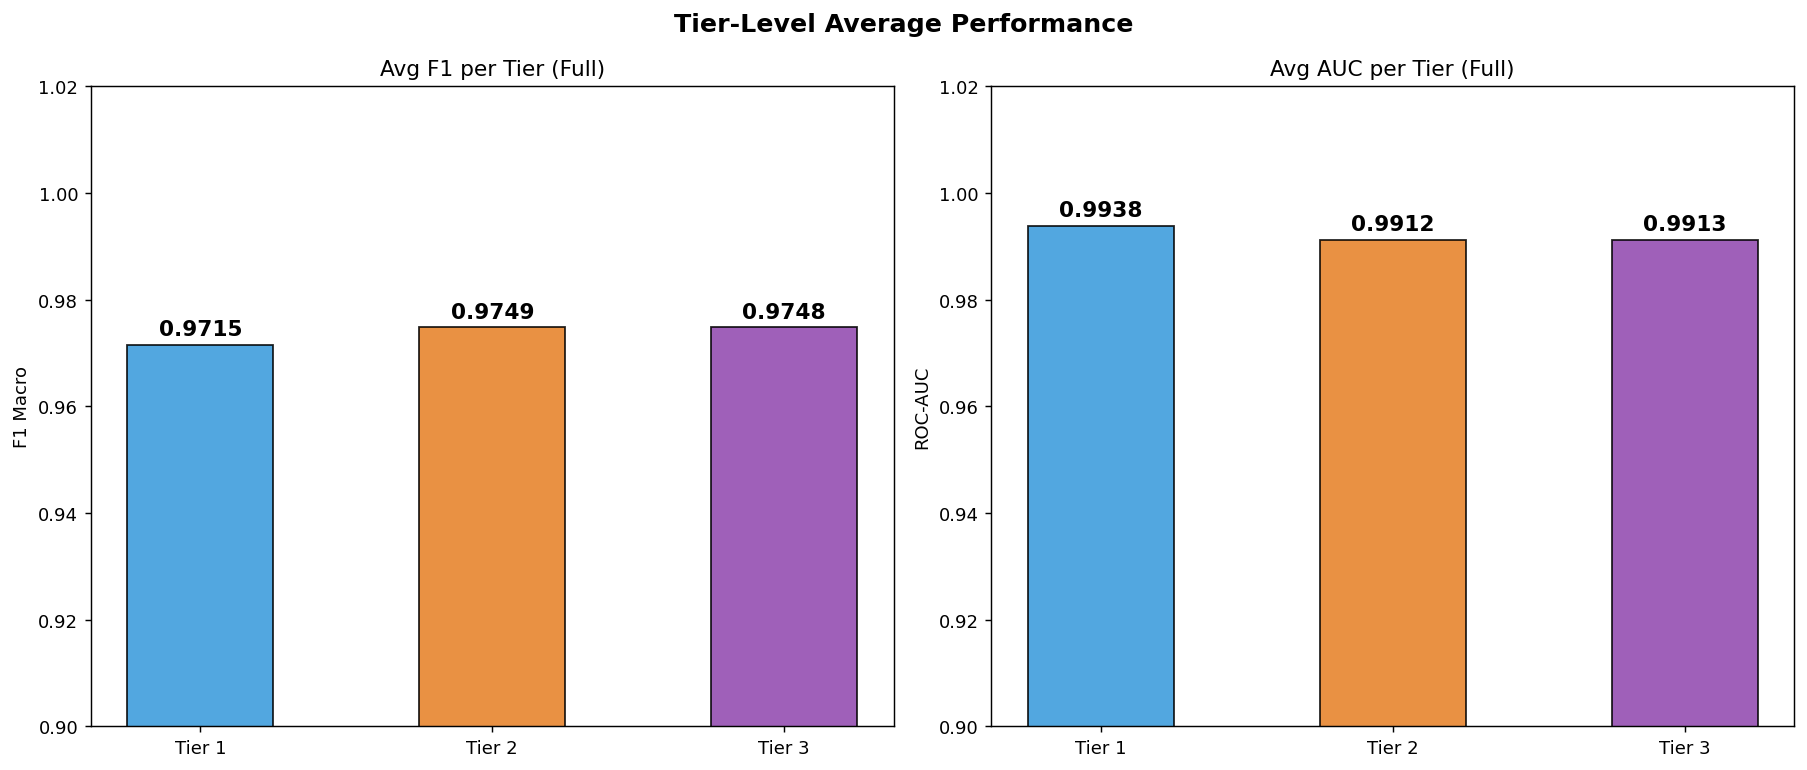

In [5]:
# VIZ 3: Tier-level average
tier_s=df_all.groupby('Tier').agg(F1=('F1_Full','mean'),AUC=('AUC_Full','mean')).reset_index()
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Tier-Level Average Performance',fontsize=14,fontweight='bold')
for ax,col,ylabel,title in [(axes[0],'F1','F1 Macro','Avg F1 per Tier (Full)'),(axes[1],'AUC','ROC-AUC','Avg AUC per Tier (Full)')]:
    t_names=tier_s['Tier'].tolist(); vals=tier_s[col].tolist()
    c=[TIER_COLORS[t] for t in t_names]
    bars=ax.bar(t_names,vals,color=c,edgecolor='black',width=0.5,alpha=0.85)
    for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,f'{v:.4f}',ha='center',va='bottom',fontsize=12,fontweight='bold')
    ax.set_ylim(0.9,1.02); ax.set_ylabel(ylabel); ax.set_title(title)
plt.tight_layout()
plt.savefig('combined_03_tier_summary.png',bbox_inches='tight',dpi=150); plt.show()

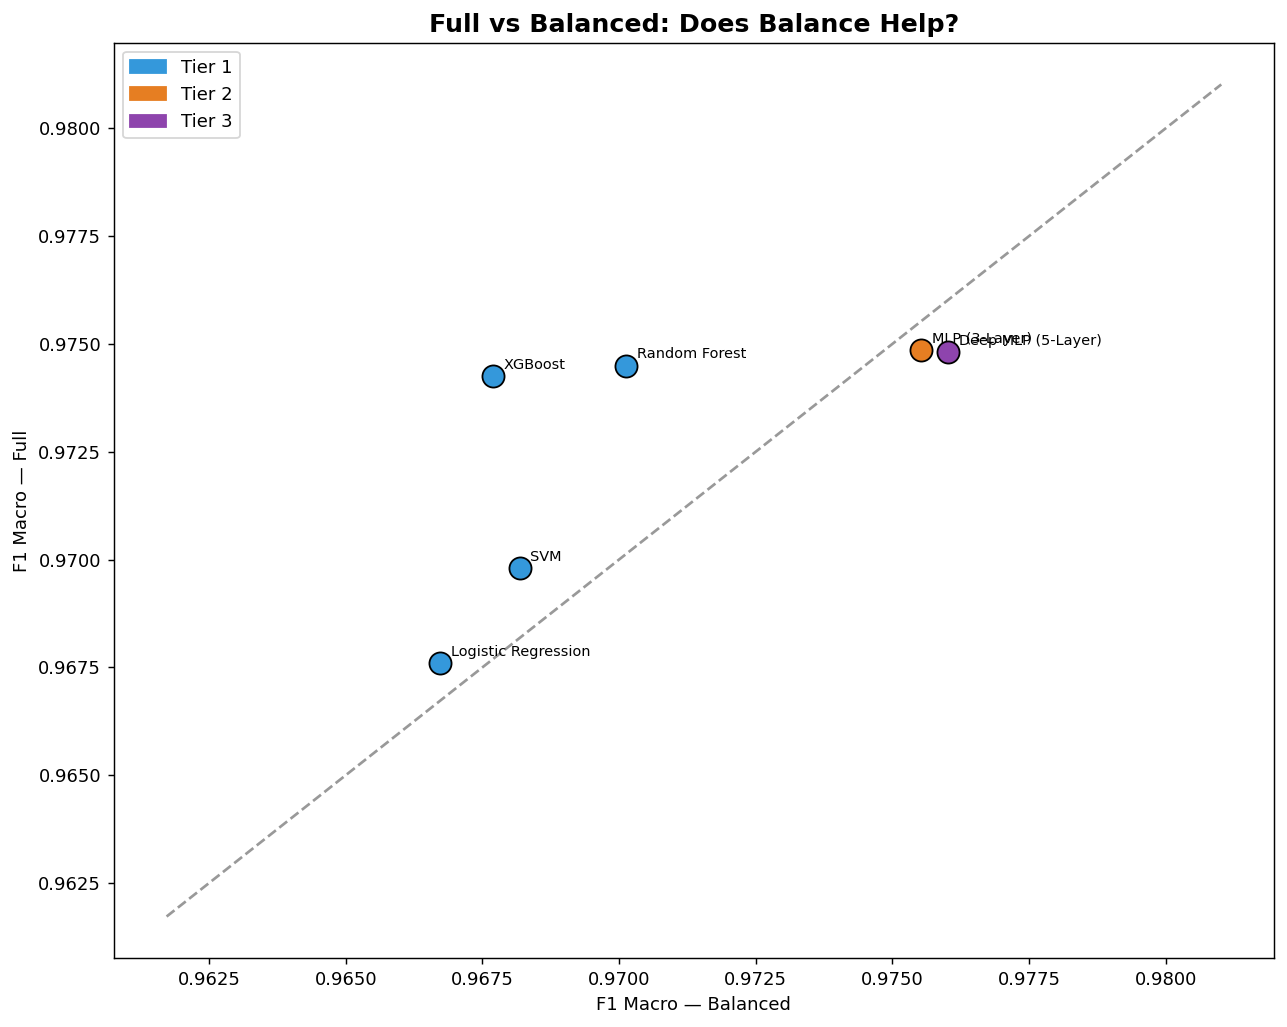

In [6]:
# VIZ 4: Full vs Balanced scatter
fig,ax=plt.subplots(figsize=(10,8))
for _,row in df_all.iterrows():
    c=TIER_COLORS[row['Tier']]
    ax.scatter(row['F1_Bal'],row['F1_Full'],s=150,color=c,edgecolors='black',zorder=5)
    ax.annotate(row['Model'],(row['F1_Bal'],row['F1_Full']),xytext=(6,4),textcoords='offset points',fontsize=8)
mn=min(df_all[['F1_Full','F1_Bal']].values.flatten())-0.005
mx=max(df_all[['F1_Full','F1_Bal']].values.flatten())+0.005
ax.plot([mn,mx],[mn,mx],'k--',alpha=0.4,label='Equal performance')
tier_patches=[mpatches.Patch(color=c,label=t) for t,c in TIER_COLORS.items()]
ax.legend(handles=tier_patches)
ax.set_xlabel('F1 Macro — Balanced'); ax.set_ylabel('F1 Macro — Full')
ax.set_title('Full vs Balanced: Does Balance Help?',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('combined_04_scatter.png',bbox_inches='tight',dpi=150); plt.show()

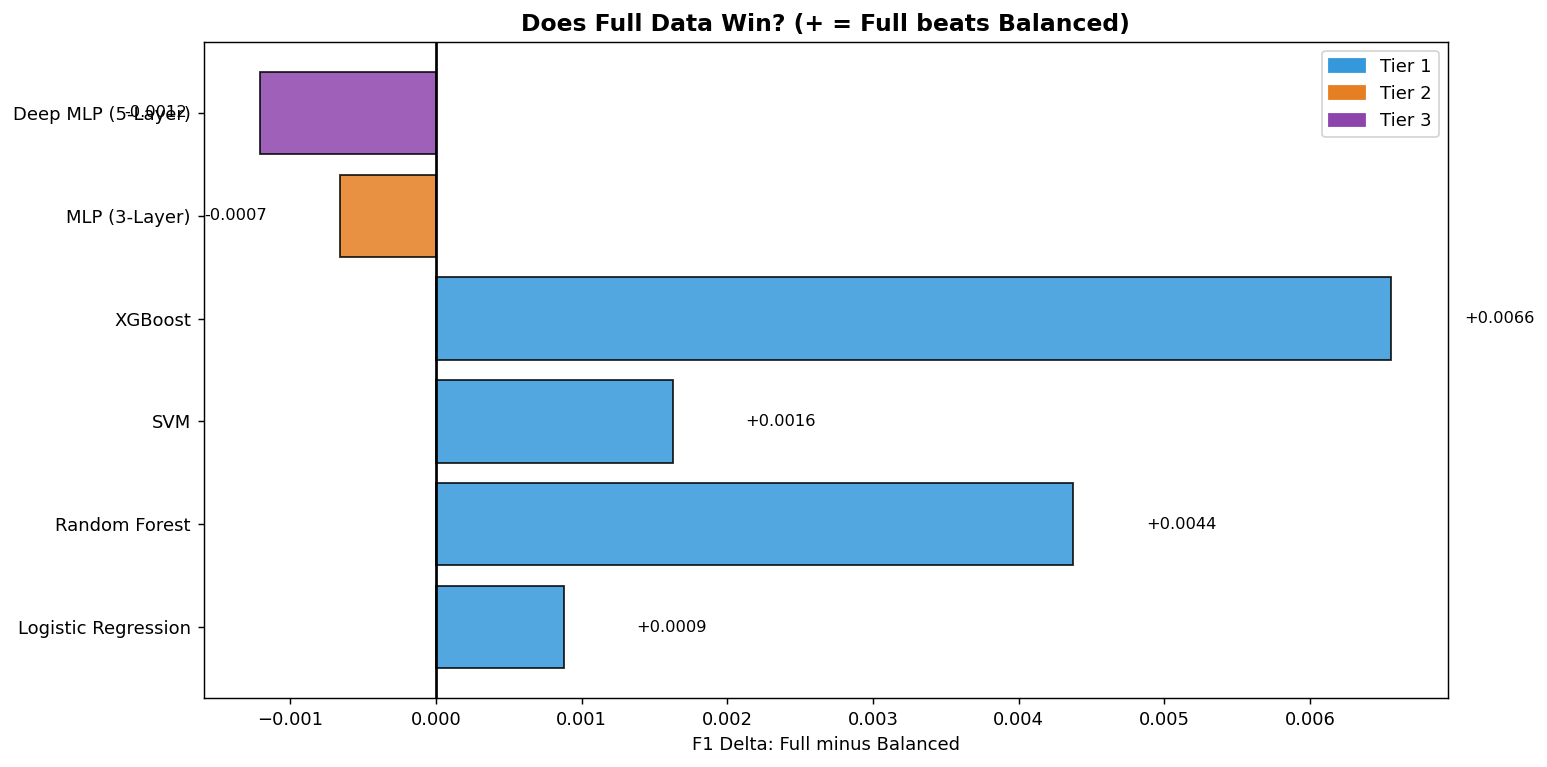

In [7]:
# VIZ 5: F1 Delta (Full minus Balanced)
df_all['F1_delta']=df_all['F1_Full']-df_all['F1_Bal']
fig,ax=plt.subplots(figsize=(12,6))
bar_c=[TIER_COLORS[t] for t in df_all['Tier']]
bars=ax.barh(df_all['Model'],df_all['F1_delta'],color=bar_c,edgecolor='black',alpha=0.85)
ax.axvline(0,color='black',lw=1.5)
for bar,v in zip(bars,df_all['F1_delta']):
    ax.text(v+0.0005 if v>=0 else v-0.0005,bar.get_y()+bar.get_height()/2,
            f'{v:+.4f}',va='center',ha='left' if v>=0 else 'right',fontsize=9)
ax.set_xlabel('F1 Delta: Full minus Balanced')
ax.set_title('Does Full Data Win? (+ = Full beats Balanced)',fontsize=13,fontweight='bold')
tier_patches=[mpatches.Patch(color=c,label=t) for t,c in TIER_COLORS.items()]
ax.legend(handles=tier_patches)
plt.tight_layout()
plt.savefig('combined_05_delta.png',bbox_inches='tight',dpi=150); plt.show()

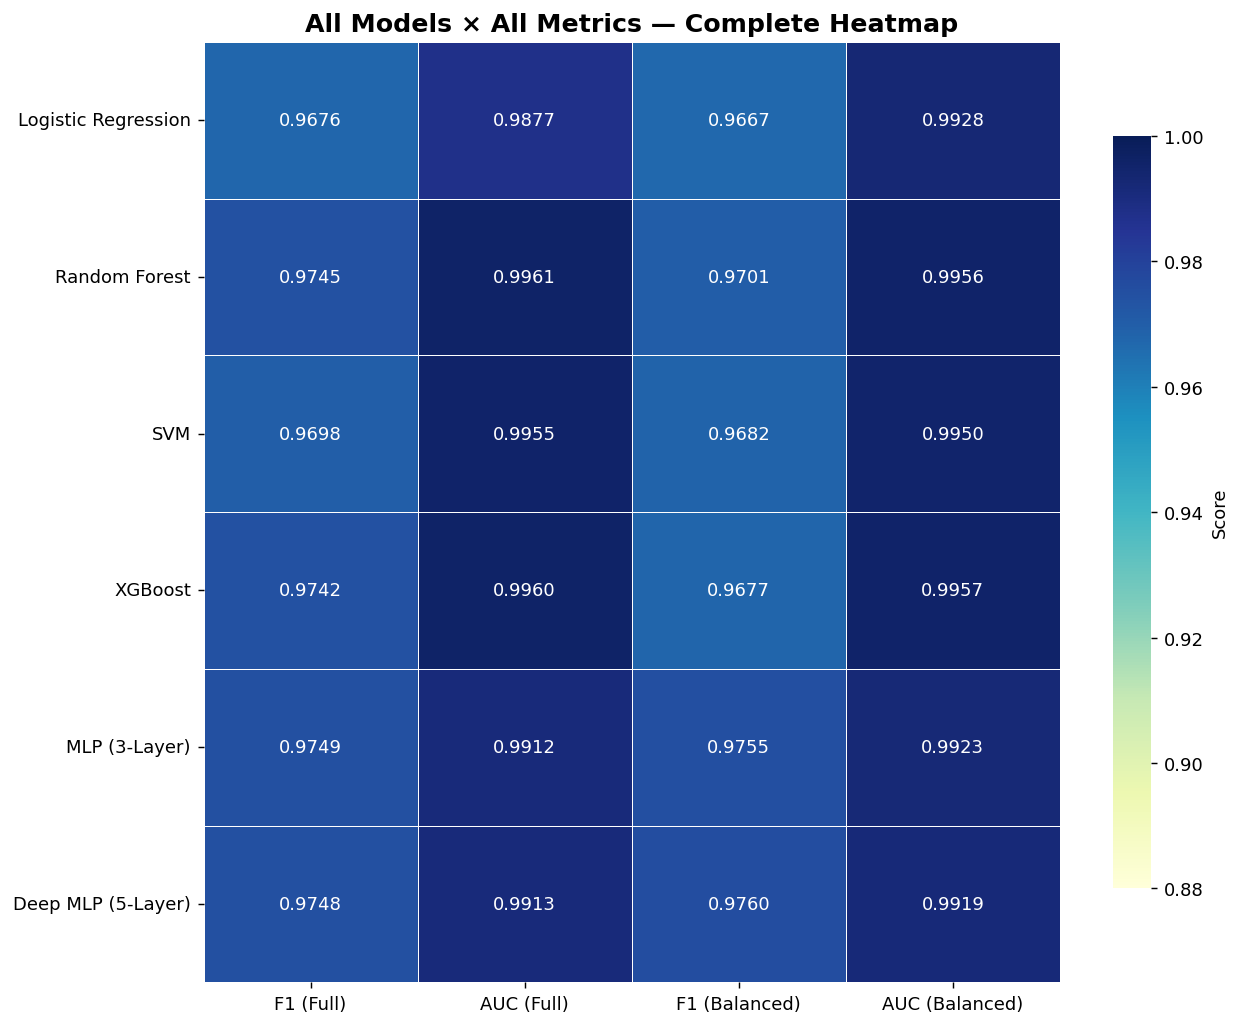

In [8]:
# VIZ 6: Complete metrics heatmap
heat=df_all.set_index('Model')[['F1_Full','AUC_Full','F1_Bal','AUC_Bal']]
heat.columns=['F1 (Full)','AUC (Full)','F1 (Balanced)','AUC (Balanced)']
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(heat,annot=True,fmt='.4f',cmap='YlGnBu',linewidths=0.5,ax=ax,
            vmin=0.88,vmax=1.0,cbar_kws={'label':'Score','shrink':0.8})
ax.set_title('All Models × All Metrics — Complete Heatmap',fontsize=14,fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('combined_06_heatmap.png',bbox_inches='tight',dpi=150); plt.show()

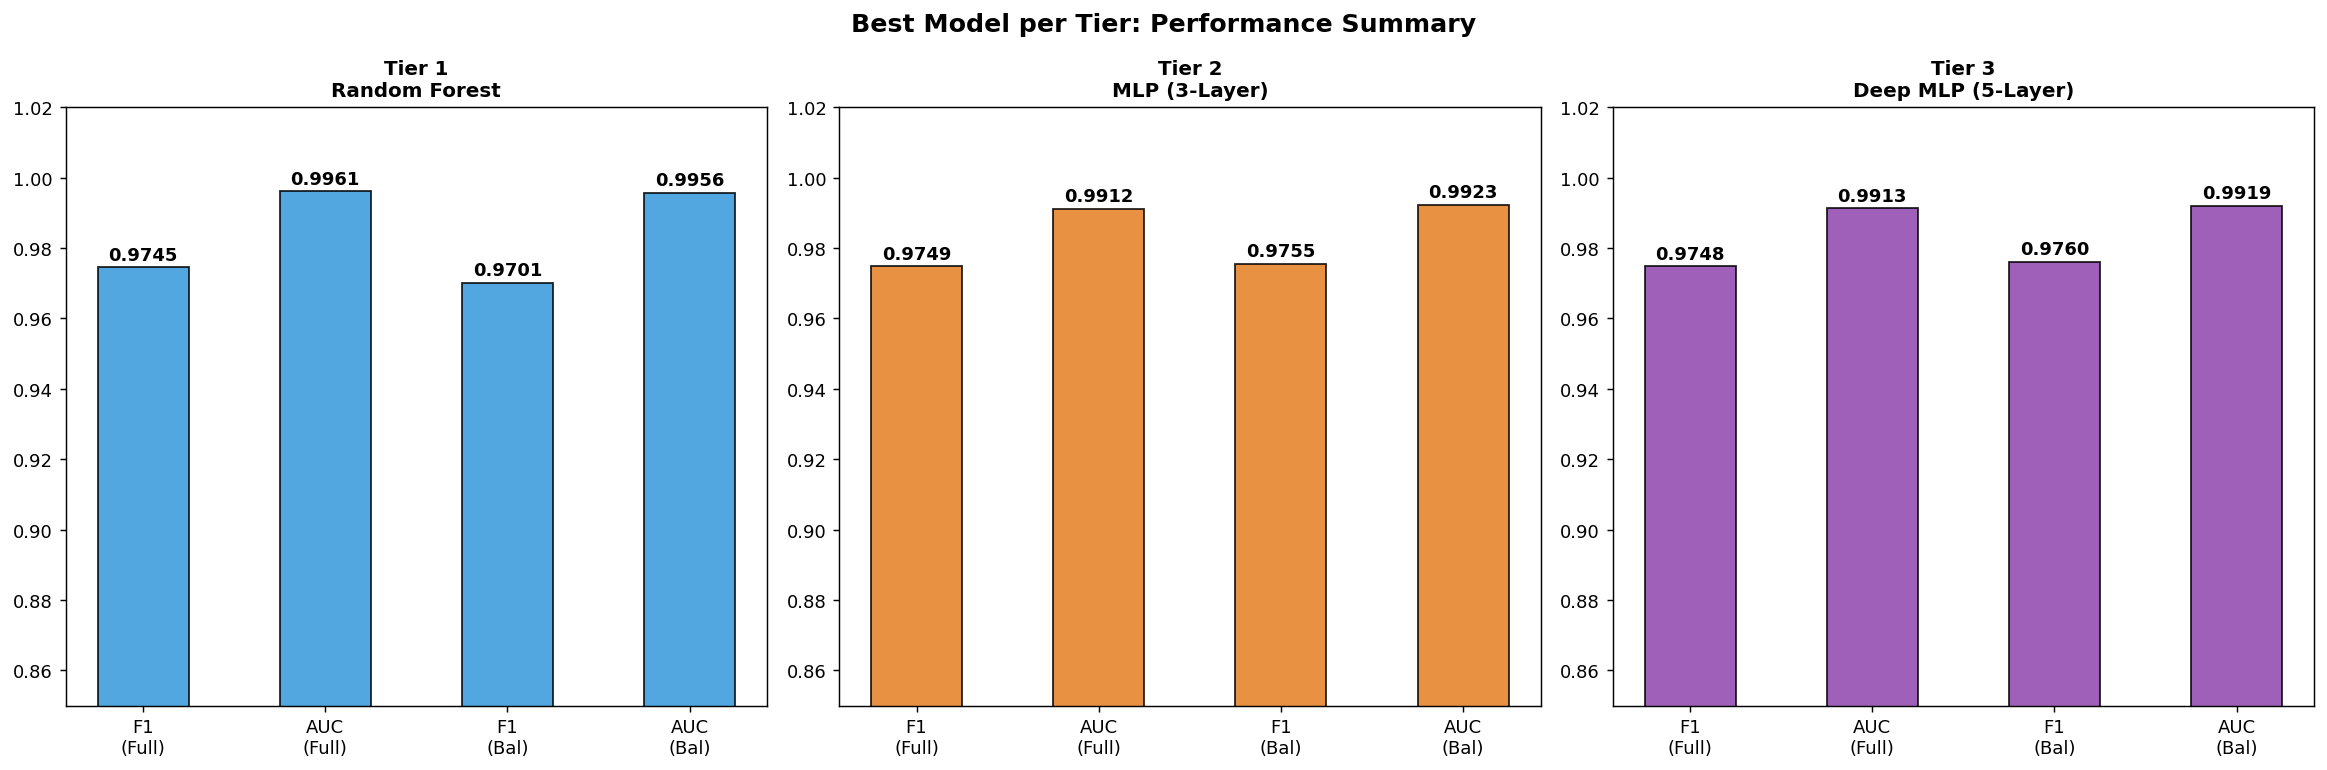

In [9]:
# VIZ 7: Best model per tier
best=df_all.loc[df_all.groupby('Tier')['F1_Full'].idxmax()]
fig,axes=plt.subplots(1,3,figsize=(18,6))
fig.suptitle('Best Model per Tier: Performance Summary',fontsize=14,fontweight='bold')
cols=['F1_Full','AUC_Full','F1_Bal','AUC_Bal']
lbls=['F1\n(Full)','AUC\n(Full)','F1\n(Bal)','AUC\n(Bal)']
for ax,(_,row) in zip(axes,best.iterrows()):
    vals=[row[c] for c in cols]
    b=ax.bar(lbls,vals,color=TIER_COLORS[row['Tier']],edgecolor='black',alpha=0.85,width=0.5)
    for bar,v in zip(b,vals): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,f'{v:.4f}',ha='center',va='bottom',fontsize=10,fontweight='bold')
    ax.set_ylim(0.85,1.02); ax.set_title(f"{row['Tier']}\n{row['Model']}",fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('combined_07_best_per_tier.png',bbox_inches='tight',dpi=150); plt.show()

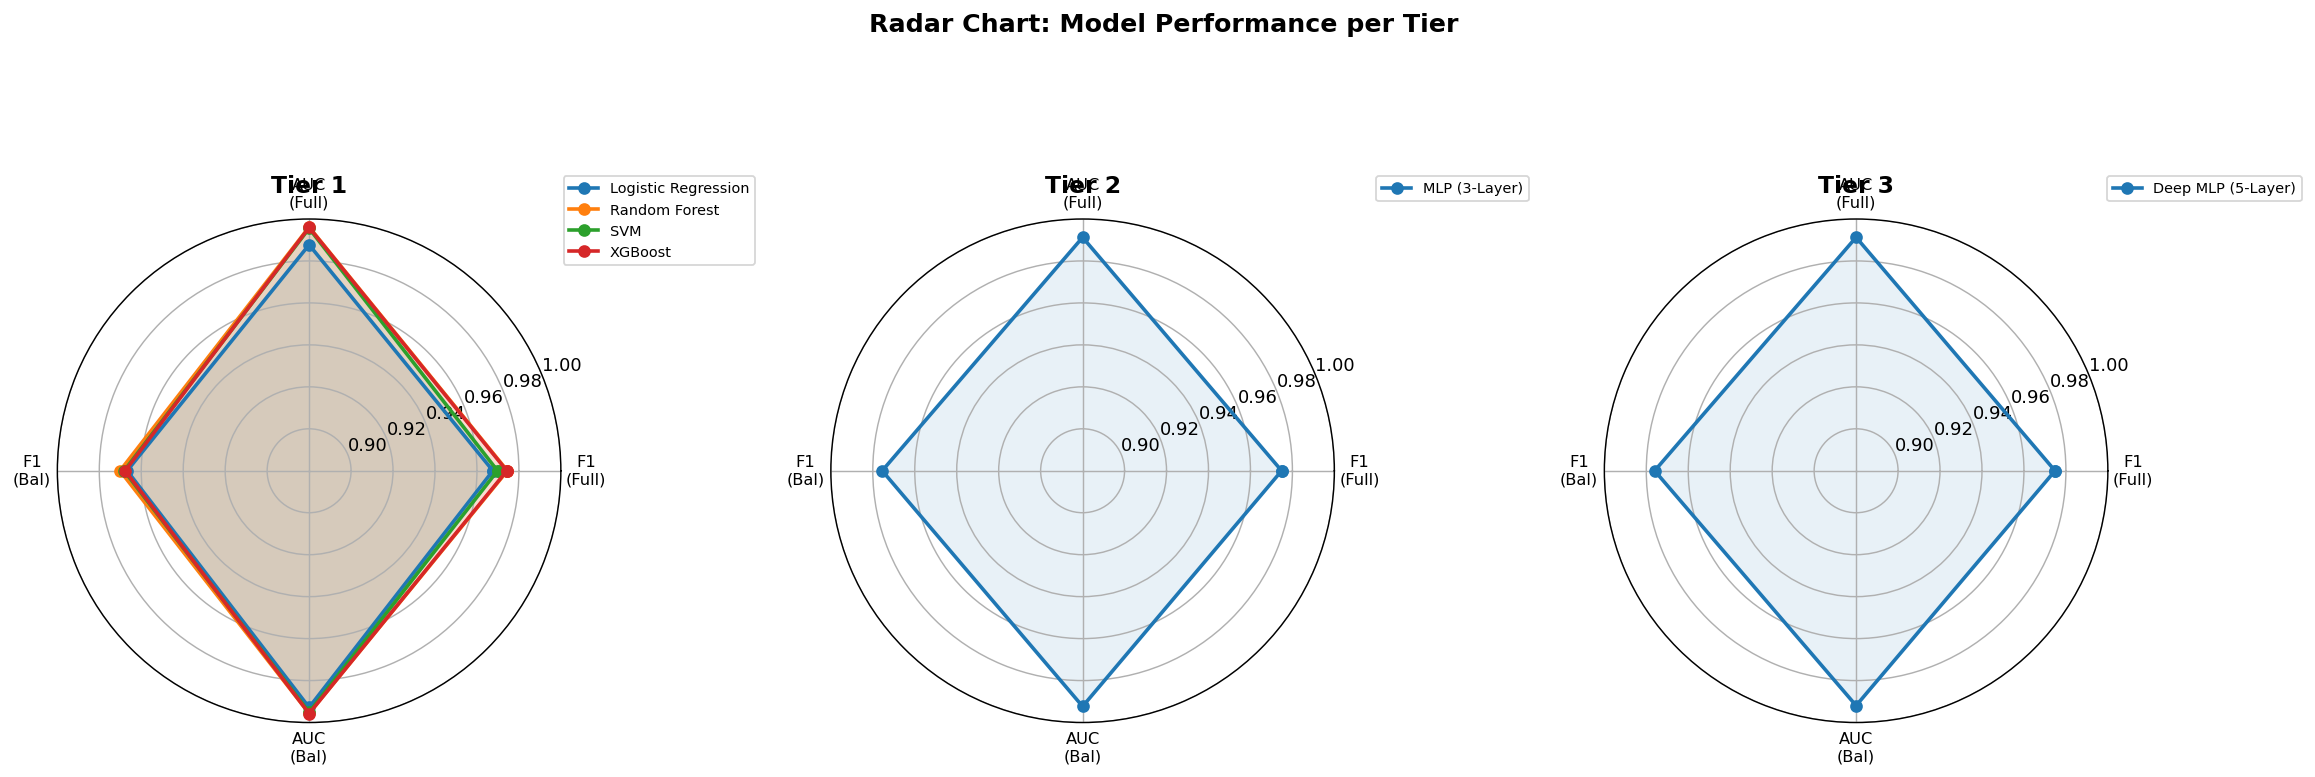

In [10]:
# VIZ 8: Radar chart per tier
categories=['F1\n(Full)','AUC\n(Full)','F1\n(Bal)','AUC\n(Bal)']
N=len(categories)
angles=np.linspace(0,2*np.pi,N,endpoint=False).tolist()+[0]
fig,axes=plt.subplots(1,3,figsize=(18,7),subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart: Model Performance per Tier',fontsize=14,fontweight='bold')
tier_models={'Tier 1':[r for r in rows[:4] if r['Tier']=='Tier 1'],
             'Tier 2':[r for r in rows if r['Tier']=='Tier 2'],
             'Tier 3':[r for r in rows if r['Tier']=='Tier 3']}
cmap=plt.cm.get_cmap('tab10')
for ax_idx,(tier_name,tier_rows) in enumerate(tier_models.items()):
    ax=axes[ax_idx]
    ax.set_title(tier_name,size=13,fontweight='bold',pad=15)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories,fontsize=9)
    ax.set_ylim(0.88,1.0)
    for i,row in enumerate(tier_rows):
        vals=[row['F1_Full'],row['AUC_Full'],row['F1_Bal'],row['AUC_Bal']]+[row['F1_Full']]
        c=cmap(i)
        ax.plot(angles,vals,'o-',lw=2,color=c,label=row['Model'])
        ax.fill(angles,vals,alpha=0.1,color=c)
    ax.legend(loc='upper right',bbox_to_anchor=(1.4,1.1),fontsize=8)
plt.tight_layout()
plt.savefig('combined_08_radar.png',bbox_inches='tight',dpi=150); plt.show()

In [11]:
print('='*75)
print('FINAL RESULTS — Intent–Behavior Deviation in Smart Contracts')
print('5-fold Stratified CV · Hybrid Features (398-d) · target: 0=safe 1=rugpull')
print('='*75)
print(f'{"Model":<22} {"Tier":<8} {"F1 Full":>14} {"AUC Full":>10} {"F1 Bal":>10} {"AUC Bal":>10}')
print('-'*75)
for _,row in df_all.iterrows():
    print(f"{row['Model']:<22} {row['Tier']:<8} "
          f"{row['F1_Full']:.4f}±{row.get('F1_Full_std',0):.4f}  "
          f"{row['AUC_Full']:>10.4f} {row['F1_Bal']:>10.4f} {row['AUC_Bal']:>10.4f}")
print('='*75)
best=df_all.loc[df_all['F1_Full'].idxmax()]
print(f"Overall best: {best['Model']} ({best['Tier']}) | F1={best['F1_Full']:.4f} | AUC={best['AUC_Full']:.4f}")
print('\nTotal plots across all 4 notebooks: ~40')
print('=== ALL COMPLETE ===')

FINAL RESULTS — Intent–Behavior Deviation in Smart Contracts
5-fold Stratified CV · Hybrid Features (398-d) · target: 0=safe 1=rugpull
Model                  Tier            F1 Full   AUC Full     F1 Bal    AUC Bal
---------------------------------------------------------------------------
Logistic Regression    Tier 1   0.9676±0.0087      0.9877     0.9667     0.9928
Random Forest          Tier 1   0.9745±0.0041      0.9961     0.9701     0.9956
SVM                    Tier 1   0.9698±0.0045      0.9955     0.9682     0.9950
XGBoost                Tier 1   0.9742±0.0045      0.9960     0.9677     0.9957
MLP (3-Layer)          Tier 2   0.9749±0.0082      0.9912     0.9755     0.9923
Deep MLP (5-Layer)     Tier 3   0.9748±0.0058      0.9913     0.9760     0.9919
Overall best: MLP (3-Layer) (Tier 2) | F1=0.9749 | AUC=0.9912

Total plots across all 4 notebooks: ~40
=== ALL COMPLETE ===
